In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys
sys.path.append("../../../")
from LRM.plotting import set_plot_style
from LRM.PottsModel import PottsModel
set_plot_style()



## Helpers (simulation)

In [2]:
#Helper functions used throughout
def get_full_neighbors(i : int, j : int, L1 : int, L2 : int):
    """Returns indices of four nearest neighbours assuming periodic boundary conditions.

    Args:
        i (int): ith row
        j (int): jth column
        L1 (int): number of rows (max row index)
        L2 (int): number of columns (max column index)

    Returns:
        _type_: tuple of pairs of indices
    """
    return [(i-1)%L1, j], [(i+1)%L1, j], [i, (j-1)%L2], [i, (j+1)%L2]


def get_half_neighbors(i : int, j : int, L1 : int, L2 : int):
    """Returns indices of four nearest neighbours assuming periodic boundary conditions.

    Args:
        i (int): ith row
        j (int): jth column
        L1 (int): number of rows (max row index)
        L2 (int): number of columns (max column index)

    Returns:
        _type_: tuple of pairs of indices
    """
    return [(i+1)%L1, j], [i, (j+1)%L2]


def unnormalized_prob(s, neighbours, T):
        return np.exp( (1/T) * sum([int(s == n) for n in neighbours]) )

def glauber_step(past_grid, T):
    
    grid = past_grid.copy()
    L = grid.shape[0]
    Xi = np.unique(grid)

    for _ in range(L * L):
        #Step 1) Randomly select a site (i,j)
        i, j = np.random.randint(0, L, size=2) 

        #Step 2) Compute conditional probability p(s | neighbours)
        neighbors = [ grid[ni, nj] for (ni,nj) in get_full_neighbors(i, j, grid.shape[0], grid.shape[1]) ]
        probs = np.array([unnormalized_prob(s, neighbors, T) for s in Xi])
        probs /= np.sum(probs)

        #Step 3) Sample new state from conditional
        grid[i, j] = np.random.choice(Xi, p=probs)
            
    return grid


def simulate_potts(L=100, q=4, T=4.0, n_sweeps=20):

    grid = np.random.choice(a=q, size = (L, L))

    for _ in range(n_sweeps):
        grid = glauber_step(past_grid=grid, T=T)

    return grid



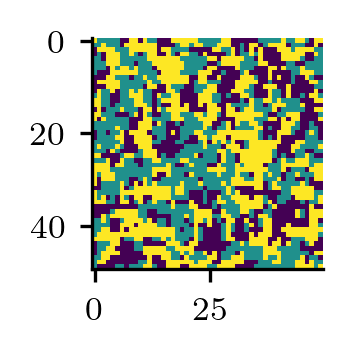

In [3]:
truth=1.3
data = simulate_potts(L=50, q=3, T=truth, n_sweeps=50)
plt.figure(figsize=(1,1))
plt.imshow(data)

In [4]:
alpha_vals = [0.0, 0.1, 0.5, 1.0, 2.0]

prior_mean = 0.5
prior_var = 10.0

mu_posts, var_posts = [], []

for alpha in alpha_vals:
    pmodel = PottsModel(grid=data, alpha=alpha)

    beta_hat, cov_hat, res = pmodel.fit_coverage(prior_mean=prior_mean, prior_var=prior_var, beta_high=1.0, B=200)

    mu_post, cov_post = pmodel.posterior(
        beta=beta_hat,
        prior_mean=prior_mean,
        prior_var=prior_var,
    )

    mu_post = float(np.asarray(mu_post).squeeze())
    var_post = float(np.asarray(cov_post).squeeze())

    mu_posts.append(mu_post)
    var_posts.append(var_post)

    print(f"alpha={alpha:.2f}: mean={mu_post:.4f}, var={var_post:.4f}, sd={np.sqrt(var_post):.4f}, cov_hat={cov_hat:.4f}, beta_hat={beta_hat:.4f}")

alpha=0.00: mean=0.8458, var=0.0011, sd=0.0330, cov_hat=0.9500, beta_hat=0.0182
alpha=0.10: mean=0.8597, var=0.0053, sd=0.0730, cov_hat=0.9500, beta_hat=0.0036
alpha=0.50: mean=0.8112, var=0.0020, sd=0.0448, cov_hat=0.9500, beta_hat=0.0097
alpha=1.00: mean=0.7686, var=0.0013, sd=0.0363, cov_hat=0.9550, beta_hat=0.0147
alpha=2.00: mean=0.7040, var=0.0006, sd=0.0245, cov_hat=0.9500, beta_hat=0.0324


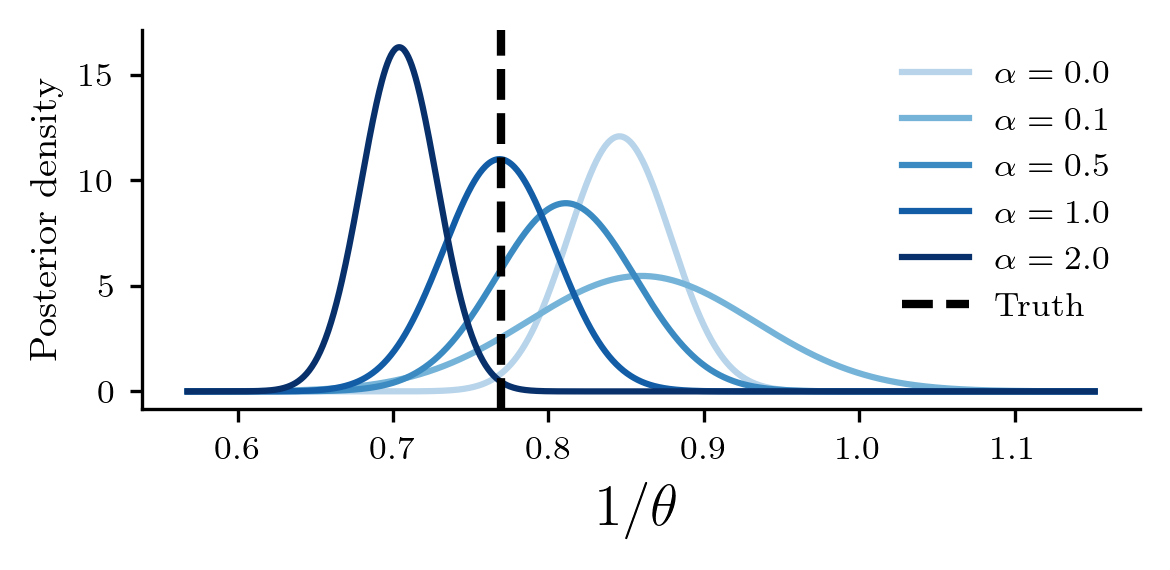

In [6]:
# Plot univariate Gaussian posteriors
mu_posts = np.array(mu_posts)
var_posts = np.array(var_posts)
sd_posts = np.sqrt(var_posts)

x_min = min(mu_posts - 4 * sd_posts)
x_max = max(mu_posts + 4 * sd_posts)
x = np.linspace(x_min, x_max, 1000)

plt.figure(figsize=(4., 2))

colors = plt.cm.Blues(np.linspace(0.3, 1., len(alpha_vals)))

for alpha, mu, var, color in zip(alpha_vals, mu_posts, var_posts, colors):
    plt.plot(
        x,
        norm.pdf(x, loc=mu, scale=np.sqrt(var)),
        color=color,
        label=fr"$\alpha={alpha}$",
    )

plt.axvline(1/truth, linestyle="--", linewidth=2, color="black", label="Truth")

plt.xlabel(r"$1/\theta$", fontsize=14)
plt.ylabel("Posterior density")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("./results/Potts-model-vary-alpha-small-grid.pdf", format="pdf", bbox_inches="tight")